In [18]:
import torch
from torch import nn
import torch.nn.functional as F 
from torch.utils.data import DataLoader
import torchvision.utils
from torchvision.models import resnet50, ResNet50_Weights

from torchvision.transforms import Compose, RandomHorizontalFlip, Normalize, Resize
from transform import show, Rotate
from dataset_build import mias, build_train_test_datasets

import os
cwd = os.getcwd()
str = os.path.join('/', *cwd.split('/')[:cwd.split('/').index('all-mias')+1])
%cd $str

/Users/parsa/Desktop/AI/A-level/Code/all-mias


In [19]:
#writer = SummaryWriter('runs/first_linear')

In [20]:
tforms = Compose([
    RandomHorizontalFlip(),
    Rotate(-30, 30, 0.3),
    Normalize((54.35747528076172,), (71.1281967163086,)) #calculated in std_mean.py
])

tforms_2 = lambda x: x/255 

def custom_tform(labels):
    a = torch.tensor([0.0,0.0])
    a[int(labels[-1].item())] = 1.0
    return a

In [21]:
train_df, test_df = build_train_test_datasets(
                'dataset_all_mias/labels/label_encoded_dataset_2.csv', 
               'dataset_all_mias/dataset_jpeg', 
               train_transform=tforms_2, 
               test_transform=tforms_2,
               train_target_transofrm=custom_tform,
               test_target_transform=custom_tform)

In [22]:
train_load, test_load = DataLoader(train_df, batch_size=10), DataLoader(test_df, batch_size=10)

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu'
print(f"Using {device} device")

#classes = {'CIRC': 0, 'NORM': 1, 'MISC': 2, 'ASYM': 3, 'ARCH': 4, 'SPIC': 5, 'CALC': 6}
classes = {0: 'abnormal', 1:'normal'}

Using mps device


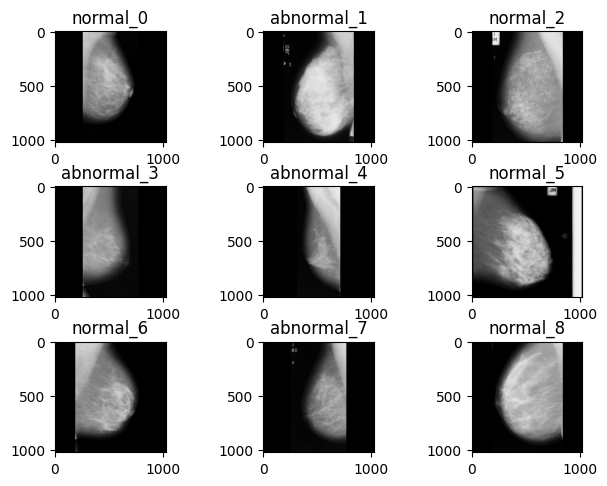

In [23]:
show(3,3, **{f'{classes[train_df[i][1].argmax().item()]}_{i}':train_df[i][0] for i in range(9)} )

In [24]:
#writer.add_images('First batch images', next(iter(train_load))[0], 0, dataformats='NCHW')
#writer.flush()

In [25]:
import torch
from torchvision.models import resnet50, ResNet50_Weights

weights = ResNet50_Weights.DEFAULT
model_conv = resnet50(weights=weights)

for param in model_conv.parameters():
    param.requires_grad = False

In [26]:
import os
import torch

print(torch.hub.get_dir())

/Users/parsa/.cache/torch/hub


In [ ]:
class GarmentClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.resnet = model_conv
        self.fc1 = nn.Linear(1000,100)
        #self.fc2 = nn.Linear(1000,100)
        self.fc3 = nn.Linear(100, 2)
        self.flatten = nn.Flatten()

    def forward(self, x):
        x = self.resnet(x)
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = nn.Sigmoid()(self.fc3(x))
        return x

In [28]:
model = GarmentClassifier().to(device)
loss_fn = torch.nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

In [29]:
loss_fn = torch.nn.BCELoss()

In [30]:
torch.ones((10,2))

tensor([[1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.]])

In [31]:
next(iter(train_load))[1]

tensor([[0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [1., 0.],
        [0., 1.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [0., 1.]])

In [33]:
m = nn.Sigmoid()

loss_fn(model(next(iter(train_load))[0].to(device)), next(iter(train_load))[1].to(device))

TypeError: Sigmoid.__init__() takes 1 positional argument but 2 were given

In [ ]:
next(iter(train_load))[1].to(device)

tensor([[0, 1],
        [1, 0],
        [0, 1],
        [1, 0],
        [1, 0],
        [0, 1],
        [0, 1],
        [1, 0],
        [0, 1],
        [0, 1]], device='mps:0')

In [24]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)
        return loss

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        print(f'start_{f}')
        f+=1

        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

    #return loss

In [25]:
model.train()
train(train_load, model, loss_fn, optimizer)

: 

In [ ]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    return 100*correct, test_loss

: 

In [ ]:
epochs = 200
train_loss = list()
accuracy = list()
test_loss = list()
f=0
print(f'start_{f}')
f+=1
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loss += train(train_load, model, loss_fn, optimizer)
    print(f'start_{f}')
    f+=1
    acc, loss = test(test_load, model, loss_fn)
    accuracy += acc
    test_loss += loss
    if loss <= min(test_loss[:-1]):
        torch.save(model.state_dict(), 'models')
print("Done!")


start_0
Epoch 1
-------------------------------
start_0
start_1
start_2
start_3


In [ ]:
import numpy as np
torch.set_printoptions(sci_mode=False)

In [ ]:
gpuified = [test_df[a][0][None, ...].to(device) for a in range(10)]

In [ ]:
a = 3
soft = nn.Softmax()

print(soft(model(gpuified[a]))*100)
print(test_df[a][1])

tensor([[13.3322, 60.8494,  0.0647,  1.6600,  0.0829,  0.6445, 23.3664]],
       device='mps:0', grad_fn=<MulBackward0>)
tensor(6)
